<a href="https://colab.research.google.com/github/chiangjasmine2026/ADALL_github/blob/main/ADALL%20Project%20Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install -U \
  scikit-learn==1.8.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 36.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
print("Setup complete")

Setup complete


In [3]:
import sklearn
print("scikit-learn version:", sklearn.__version__)


scikit-learn version: 1.8.0


In [4]:
# Example: Replace this with the raw URL of your GitHub file
github_raw_url = 'https://raw.githubusercontent.com/chiangjasmine2026/ADALL_github/refs/heads/main/diabetes_012_health_indicators_BRFSS2015.csv'
try:
    df = pd.read_csv(github_raw_url)
    print("Successfully loaded data from GitHub!")
    display(df.head())
except Exception as e:
    print(f"Error loading data: {e}")
    print("Please ensure the URL is correct and the file format is compatible with `pd.read_csv`.")

Successfully loaded data from GitHub!


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
import pandas as pd
import numpy as np
from io import StringIO
# ---------------------------
# Generate a full dataset profile
# ---------------------------
buffer = StringIO()

# dtypes
buffer.write("=== DTYPES ===\n")
buffer.write(df.dtypes.to_string())
buffer.write("\n\n")

# numeric describe
buffer.write("=== NUMERIC DESCRIBE ===\n")
buffer.write(df.describe().to_string())
buffer.write("\n\n")

# categorical describe
buffer.write("=== CATEGORICAL DESCRIBE ===\n")
try:
    buffer.write(df.describe(include='object').to_string())
except:
    buffer.write("No categorical columns")
buffer.write("\n\n")

# null summary
buffer.write("=== NULL SUMMARY ===\n")
null_summary = (
    df.isna().sum().to_frame("null_count")
    .assign(null_pct=lambda x: x["null_count"]/len(df))
)
buffer.write(null_summary.to_string())
buffer.write("\n\n")

# unique cardinality
buffer.write("=== UNIQUE VALUES PER COLUMN ===\n")
buffer.write(df.nunique().to_frame("unique_count").to_string())
buffer.write("\n\n")

# correlation matrix
buffer.write("=== CORRELATIONS (NUMERIC ONLY) ===\n")
buffer.write(df.corr(numeric_only=True).round(3).to_string())
buffer.write("\n\n")

# value counts for categoricals
buffer.write("=== VALUE COUNTS (TOP 20 PER CATEGORICAL COLUMN) ===\n")
cat_cols = df.select_dtypes(include='object').columns
if len(cat_cols) > 0:
    for col in cat_cols:
        buffer.write(f"\nColumn: {col}\n")
        vc = df[col].value_counts().head(20)
        buffer.write(vc.to_string())
        buffer.write("\n")
else:
    buffer.write("No categorical columns\n")
buffer.write("\n")

# --------- FIXED OUTLIER COMPUTATION (NO BOOLEANS) ---------
buffer.write("=== OUTLIER SUMMARY (IQR METHOD) ===\n")
num_cols = df.select_dtypes(include=['number']).columns  # exclude booleans
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[num_cols] < (Q1 - 1.5*IQR)) | (df[num_cols] > (Q3 + 1.5*IQR))).sum()
buffer.write(outliers.to_string())
buffer.write("\n\n")

# leakage scan: columns with all unique values
buffer.write("=== POSSIBLE LEAKAGE COLUMNS (UNIQUE FOR EACH ROW) ===\n")
leak_cols = df.columns[df.nunique() == len(df)]
buffer.write(str(list(leak_cols)))
buffer.write("\n\n")

# shape, duplicates, constant cols
buffer.write("=== SHAPE / DUPLICATES / CONSTANT COLUMNS ===\n")
dup_count = df.duplicated().sum()
constant_cols = df.columns[df.nunique() == 1].tolist()
buffer.write(f"Rows: {len(df)}, Columns: {df.shape[1]}\n")
buffer.write(f"Duplicate rows: {dup_count}\n")
buffer.write(f"Constant columns: {constant_cols}\n\n")

# Final text
payload_text = buffer.getvalue()

print(payload_text)


=== DTYPES ===
Diabetes_012            float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64

=== NUMERIC DESCRIBE ===
        Diabetes_012         HighBP       HighChol      CholCheck            BMI         Smoker         Stroke  HeartDiseaseorAttack   PhysActivity         Fruits        Veggies  HvyAlcoholConsump  AnyHealthcare    NoDocbcCost        GenHlth       MentHlt

In [6]:
from google.colab import userdata
from openai import OpenAI
# Load key from Google Colab Secrets
api_key = userdata.get('OPENAI_API_KEY')
client = OpenAI(
    api_key=api_key,
)

In [7]:
# response = client.responses.create(
#     model="gpt-5-mini",
#     instructions="""
# You are an expert data scientist with extensive knowledge of tree-based models.
# Always justify recommendations using reasoning trace based ONLY on the dataset profile.
# """,
#     input=f"""
# Dataset info: {payload_text}\n
# Questions:\n
# 1. Based on the dataset profile, what data quality issues should be resolved before modelling?
# Provide a priority list and justify each item. \n
# 2. Which columns appear redundant, correlated, or likely to cause leakage?
# Explain why each is problematic. \n
# Next: Provide a python script to handle the identified issues.
# Define one helper function for each issue.
# Then define a wrapper function that calls these helper with true false option as user choice
# Provide a single line of code to run the overall wrapper function.
# Do not encode categorical columns or model first.
# """)
# print(response.output_text)

In [8]:
import pandas as pd
import numpy as np
from sklearn.utils import resample

def check_missing_and_duplicates(df, verbose=True):
    """Check for missing values and duplicates. Returns df unchanged but raises if missing present when verbose=True."""
    missing = df.isnull().sum()
    total_missing = missing.sum()
    if verbose:
        print("Total missing values:", int(total_missing))
        if total_missing > 0:
            print(missing[missing > 0])
        dup_count = df.duplicated(keep=False).sum()
        print("Duplicate rows count:", int(dup_count))
    return df

def drop_constant_columns(df, verbose=True):
    """Drop any constant columns (zero variance)."""
    nunique = df.nunique(dropna=False)
    const_cols = nunique[nunique <= 1].index.tolist()
    if verbose:
        print("Constant columns to drop:", const_cols)
    if const_cols:
        df = df.drop(columns=const_cols)
    return df

def remove_highly_correlated(df, target_col='target', threshold=0.95, verbose=True):
    """
    Remove highly correlated features (pairwise abs corr > threshold).
    For each correlated pair, keep the column with larger absolute Pearson correlation with target_col.
    """
    # work on numeric columns only
    numeric = df.select_dtypes(include=[np.number]).columns.tolist()
    if target_col not in numeric:
        raise ValueError("target_col must be numeric and present in df")
    features = [c for c in numeric if c != target_col]
    corr = df[features].corr().abs()

    to_drop = set()
    # precompute abs correlation with target
    abs_corr_with_target = df[features].corrwith(df[target_col]).abs()

    # iterate upper triangle pairs
    cols = corr.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            c1 = cols[i]; c2 = cols[j]
            if corr.iloc[i, j] > threshold:
                # compare correlation with target; if equal use variance as tie-breaker (drop the lower variance)
                corr1 = abs_corr_with_target.get(c1, 0.0)
                corr2 = abs_corr_with_target.get(c2, 0.0)
                if corr1 > corr2:
                    drop_col = c2
                elif corr2 > corr1:
                    drop_col = c1
                else:
                    # tie-breaker: drop the one with smaller variance
                    var1 = df[c1].var()
                    var2 = df[c2].var()
                    drop_col = c1 if var1 < var2 else c2
                # don't drop target accidentally
                if drop_col != target_col:
                    to_drop.add(drop_col)

    if verbose:
        print(f"Removing {len(to_drop)} highly correlated columns (threshold={threshold}):", sorted(list(to_drop)))
    df = df.drop(columns=list(to_drop))
    return df

def cap_outliers_iqr(df, multiplier=1.5, exclude=None, verbose=True):
    """
    Cap values outside [Q1 - multiplier*IQR, Q3 + multiplier*IQR] for numeric columns.
    exclude: list of columns to exclude from capping (e.g., target_col). By default exclude 'target' if present.
    """
    if exclude is None:
        exclude = []
    if 'target' in df.columns and 'target' not in exclude:
        exclude = exclude + ['target']
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cols_to_cap = [c for c in numeric_cols if c not in exclude]
    capped_info = {}
    for col in cols_to_cap:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR
        before_min = df[col].min()
        before_max = df[col].max()
        df[col] = df[col].clip(lower=lower, upper=upper)
        after_min = df[col].min()
        after_max = df[col].max()
        capped_info[col] = (before_min, before_max, after_min, after_max)
    if verbose:
        # Print a brief summary for columns that changed ranges
        changed = {k:v for k,v in capped_info.items() if v[0]!=v[2] or v[1]!=v[3]}
        print("Columns with range changes after IQR capping:", list(changed.keys()))
    return df

def resample_classes(df, target_col='target', method='none', random_state=42, verbose=True):
    """
    Resample dataset to address class imbalance.
    method options: 'none' | 'oversample' | 'undersample'
    - oversample: upsample minority class to match majority
    - undersample: downsample majority class to match minority
    Returns a new DataFrame (shuffled).
    """
    if method not in ('none', 'oversample', 'undersample'):
        raise ValueError("method must be one of 'none','oversample','undersample'")
    if method == 'none':
        if verbose:
            print("No resampling performed.")
        return df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

    # split classes
    classes = df[target_col].unique().tolist()
    if len(classes) != 2:
        raise ValueError("resample_classes currently supports binary target only")
    class0 = df[df[target_col] == classes[0]]
    class1 = df[df[target_col] == classes[1]]
    # determine majority/minority
    if len(class0) > len(class1):
        majority, minority = class0, class1
    else:
        majority, minority = class1, class0

    if method == 'oversample':
        minority_up = resample(minority,
                               replace=True,
                               n_samples=len(majority),
                               random_state=random_state)
        df_resampled = pd.concat([majority, minority_up], axis=0)
    else:  # undersample
        majority_down = resample(majority,
                                 replace=False,
                                 n_samples=len(minority),
                                 random_state=random_state)
        df_resampled = pd.concat([majority_down, minority], axis=0)

    df_resampled = df_resampled.sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    if verbose:
        counts = df_resampled[target_col].value_counts().to_dict()
        print(f"Resampled class counts ({method}):", counts)
    return df_resampled

def preprocess_dataset(df,
                       target_col='target',
                       remove_constants=True,
                       remove_correlated=True,
                       corr_threshold=0.95,
                       cap_outliers=True,
                       outlier_multiplier=1.5,
                       resample_method='none',
                       random_state=42,
                       verbose=True):
    """
    Wrapper that runs a sequence of preprocessing steps. Each step can be toggled.
    Returns the processed DataFrame.
    """
    # 1) Basic checks
    if verbose:
        print("Starting preprocessing...")
    df = check_missing_and_duplicates(df, verbose=verbose)

    # 2) Drop constant columns
    if remove_constants:
        df = drop_constant_columns(df, verbose=verbose)

    # 3) Remove highly correlated features
    if remove_correlated:
        df = remove_highly_correlated(df, target_col=target_col, threshold=corr_threshold, verbose=verbose)

    # 4) Cap outliers
    if cap_outliers:
        df = cap_outliers_iqr(df, multiplier=outlier_multiplier, exclude=[target_col], verbose=verbose)

    # 5) Resample for class imbalance (if requested)
    if resample_method != 'none':
        df = resample_classes(df, target_col=target_col, method=resample_method, random_state=random_state, verbose=verbose)
    else:
        if verbose:
            print("Skipping resampling step.")

    if verbose:
        print("Preprocessing complete. Resulting shape:", df.shape)
    return df

df_clean = preprocess_dataset(df,
                              target_col='target',
                              remove_constants=False,
                              remove_correlated=False,
                              corr_threshold=0.95,
                              cap_outliers=False,
                              outlier_multiplier=1.5,
                              resample_method='none',
                              random_state=42,
                              verbose=True)


Starting preprocessing...
Total missing values: 0
Duplicate rows count: 35086
Skipping resampling step.
Preprocessing complete. Resulting shape: (253680, 22)


In [9]:
TARGET_COL = "Diabetes_012"  # change for your dataset
df[TARGET_COL].value_counts()

,count
Diabetes_012,
0.0,213703
2.0,35346
1.0,4631


In [10]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train.shape, X_test.shape

((202944, 21), (50736, 21))

In [11]:
num_cols = X_train.select_dtypes(exclude=["object","category"]).columns
cat_cols = X_train.select_dtypes(include=["object","category"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

num_cols[:10], cat_cols[:10]


(Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
        'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies'],
       dtype='object'),
 Index([], dtype='object'))

In [12]:
# ------------------------------------
# Decision Tree (Classification) + GridSearch (MCC) + Print Tree
# ------------------------------------

import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import matthews_corrcoef, make_scorer

# Stratified CV keeps class balance similar across splits
cv = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

# MCC scorer (higher is better)
mcc_scorer = make_scorer(matthews_corrcoef)

# -------------------------------------------
# 1) Pipeline
# -------------------------------------------
pipe_dt = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# -------------------------------------------
# 2) Small param grid (fast)
# -------------------------------------------
param_grid_dt = {
    "classifier__max_depth": [8, 15], #lets use a deeper tree to illustrate the need for Feature Importance
    "classifier__criterion": ["gini", "entropy", "log_loss"]
}

# -------------------------------------------
# 3) GridSearchCV
# -------------------------------------------
gs_dt = GridSearchCV(
    estimator=pipe_dt,
    param_grid=param_grid_dt,
    cv=cv,
    scoring=mcc_scorer,
    n_jobs=-1,
    verbose=1
)

# -------------------------------------------
# 4) Fit
# -------------------------------------------
gs_dt.fit(X_train, y_train)
print("Decision Tree grid search complete.")
print("Best DT Params:", gs_dt.best_params_)
print("Best CV MCC:", gs_dt.best_score_)

# -------------------------------------------
# 5) Test MCC
# -------------------------------------------
dt_best = gs_dt.best_estimator_
dt_pred = dt_best.predict(X_test)
print("\nTest MCC (Decision Tree):", matthews_corrcoef(y_test, dt_pred))

# -------------------------------------------
# 6) Print the tree rules (text)
# -------------------------------------------
# Get feature names after preprocessing (works for ColumnTransformer in recent sklearn)
pre = dt_best.named_steps["preprocessor"]
clf = dt_best.named_steps["classifier"]

try:
    feature_names = pre.get_feature_names_out()
except Exception:
    feature_names = [f"f{i}" for i in range(clf.n_features_in_)]

tree_text = export_text(clf, feature_names=list(feature_names), max_depth=6)
print("\nDecision Tree (first 6 levels):\n")
print(tree_text)




Fitting 10 folds for each of 6 candidates, totalling 60 fits
Decision Tree grid search complete.
Best DT Params: {'classifier__criterion': 'entropy', 'classifier__max_depth': 8}
Best CV MCC: 0.2265156819978525

Test MCC (Decision Tree): 0.21618677237115128

Decision Tree (first 6 levels):

|--- num__HighBP <= 0.50
|   |--- num__GenHlth <= 2.50
|   |   |--- num__Age <= 8.50
|   |   |   |--- num__BMI <= 28.50
|   |   |   |   |--- num__GenHlth <= 1.50
|   |   |   |   |   |--- num__Age <= 6.50
|   |   |   |   |   |   |--- num__BMI <= 23.50
|   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |--- num__BMI >  23.50
|   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |--- num__Age >  6.50
|   |   |   |   |   |   |--- num__Sex <= 0.50
|   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |--- num__Sex >  0.50
|   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- num__GenHlth

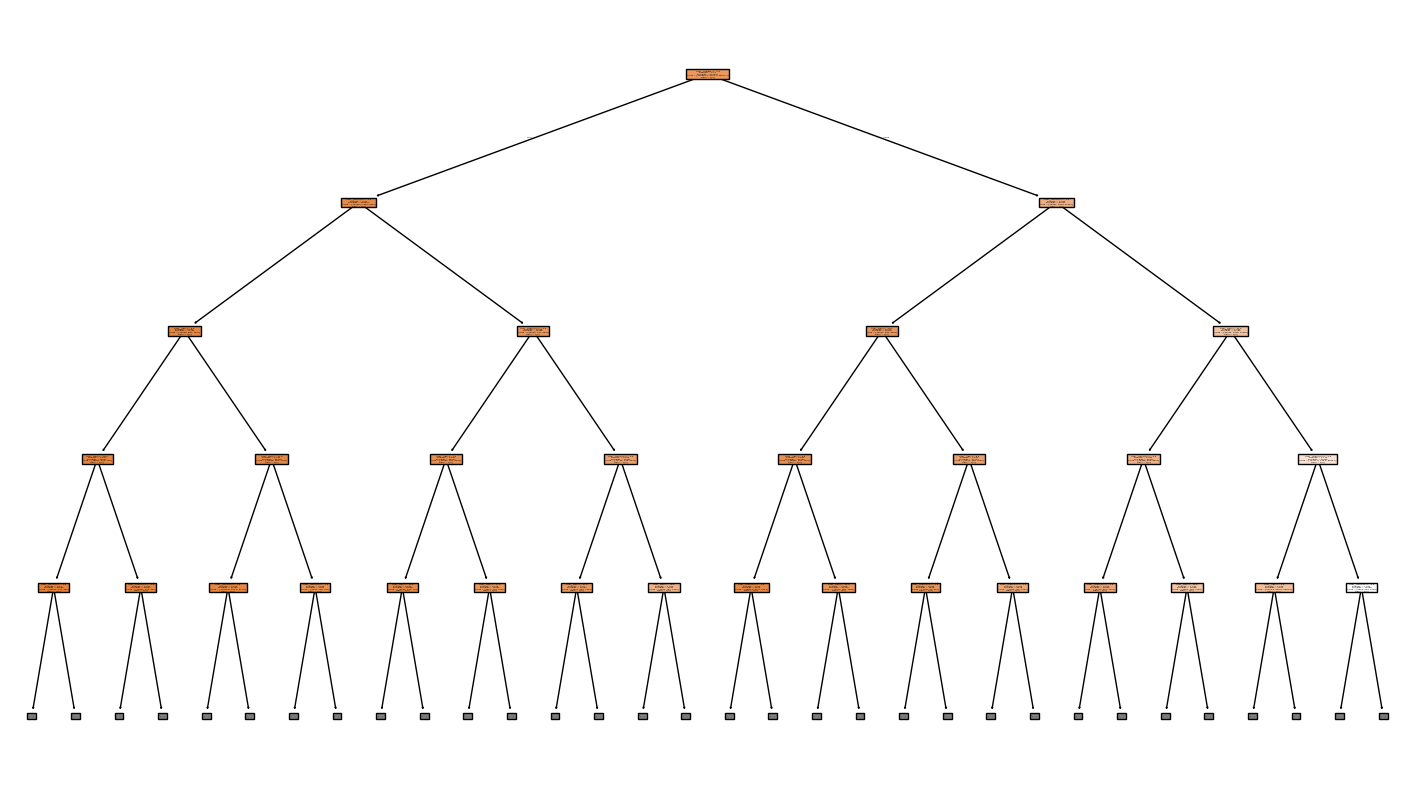

In [13]:
# -------------------------------------------
# Optional: plot tree (needs matplotlib)
# -------------------------------------------
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(18, 10))
plot_tree(clf, feature_names=feature_names, class_names=True, filled=True, max_depth=4)
plt.show()

In [14]:
# -------------------------------------------
# 7) Feature Importance (FI) from the best Decision Tree
# (use clear names so it won't clash with XGB variables)
# -------------------------------------------
import pandas as pd

dt_preproc = dt_best.named_steps["preprocessor"]
dt_clf = dt_best.named_steps["classifier"]

# Get feature names after preprocessing
try:
    dt_feature_names = dt_preproc.get_feature_names_out()
except Exception:
    dt_feature_names = [f"f{i}" for i in range(dt_clf.n_features_in_)]

# DecisionTreeClassifier has feature_importances_
dt_fi = pd.Series(dt_clf.feature_importances_, index=dt_feature_names)

# Sort high to low, and drop zeros for readability (optional)
dt_fi_sorted = dt_fi.sort_values(ascending=False)
dt_fi_nonzero = dt_fi_sorted[dt_fi_sorted > 0]

print("\nTop Feature Importances (Decision Tree):")
print(dt_fi_nonzero.head(20))


Top Feature Importances (Decision Tree):
num__HighBP                  0.382800
num__GenHlth                 0.288980
num__BMI                     0.130072
num__Age                     0.089913
num__HighChol                0.063761
num__Income                  0.009358
num__HeartDiseaseorAttack    0.007042
num__Sex                     0.006097
num__HvyAlcoholConsump       0.005588
num__DiffWalk                0.004013
num__Education               0.003586
num__MentHlth                0.002383
num__PhysHlth                0.002336
num__CholCheck               0.001475
num__Stroke                  0.000726
num__AnyHealthcare           0.000591
num__Veggies                 0.000430
num__Smoker                  0.000362
num__NoDocbcCost             0.000172
num__PhysActivity            0.000170
dtype: float64


In [15]:
# ------------------------------------
# 0. NOTE: This block takes quite a while to run, do it before moving onto explanation of code
# ------------------------------------

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# For classification, prefer stratified splits so class balance is similar in each split
cv = StratifiedShuffleSplit(n_splits=3, test_size=0.2, random_state=42)

# -------------------------------------------
# 1. Create pipelines for both models
# -------------------------------------------

pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

pipe_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss"  # sensible default for binary classification
    ))
])

# -------------------------------------------
# 2. Define parameter grids
# Keep them small for speed and simplicity
# -------------------------------------------

param_grid_rf = {
    "classifier__n_estimators": [50, 200],
    "classifier__max_depth": [5, 10],
    "classifier__criterion": ["gini", "entropy", "log_loss"]
}

param_grid_xgb = {
    "classifier__n_estimators": [50, 200],
    "classifier__max_depth": [2, 4],
    "classifier__eval_metric": ["logloss", "auc"]
}

# -------------------------------------------
# 3. Create GridSearchCV objects
# -------------------------------------------
#make scorer mcc
from sklearn.metrics import make_scorer, matthews_corrcoef


gs_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    cv=cv,
    scoring="matthews_corrcoef",
    n_jobs=-1,
    verbose=1
)

gs_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    cv=cv,
    scoring="matthews_corrcoef",
    n_jobs=-1,
    verbose=1
)

# -------------------------------------------
# 4. Fit both models
# (Students can run one at a time if needed)
# -------------------------------------------

gs_rf.fit(X_train, y_train)
print("Random Forest grid search complete.")

gs_xgb.fit(X_train, y_train)
print("XGBoost grid search complete.")

# -------------------------------------------
# 5. Evaluate on test set
# -------------------------------------------

from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef

rf_pred = gs_rf.best_estimator_.predict(X_test)
xgb_pred = gs_xgb.best_estimator_.predict(X_test)

print("\nRF MCC:", matthews_corrcoef(y_test, rf_pred))
print("Best RF Params:", gs_rf.best_params_)
print("\nRF Classification Report:\n", classification_report(y_test, rf_pred))
print("RF Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))

print("\nXGB MCC:", matthews_corrcoef(y_test, xgb_pred))
print("Best XGB Params:", gs_xgb.best_params_)
print("\nXGB Classification Report:\n", classification_report(y_test, xgb_pred))
print("XGB Confusion Matrix:\n", confusion_matrix(y_test, xgb_pred))


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Random Forest grid search complete.
Fitting 3 folds for each of 8 candidates, totalling 24 fits
XGBoost grid search complete.

RF MCC: 0.19944181032698524
Best RF Params: {'classifier__criterion': 'gini', 'classifier__max_depth': 10, 'classifier__n_estimators': 50}

RF Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      0.99      0.92     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.58      0.11      0.18      7069

    accuracy                           0.85     50736
   macro avg       0.48      0.37      0.37     50736
weighted avg       0.80      0.85      0.80     50736

RF Confusion Matrix:
 [[42252     0   489]
 [  875     0    51]
 [ 6316     0   753]]

XGB MCC: 0.2599078824863302
Best XGB Params: {'classifier__eval_metric': 'logloss', 'classifier__max_depth': 2, 'classifier__n_estimators': 200}

XGB Classification Report:
    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packag

In [16]:
# -------------------------------------------
# 6) Feature Importance (FI) for the best XGBoost model (from GridSearch)
# (use clear names so it won't clash with DT variables)
# -------------------------------------------
import numpy as np
import pandas as pd

xgb_best_pipe = gs_xgb.best_estimator_
xgb_preproc = xgb_best_pipe.named_steps["preprocessor"]
xgb_clf = xgb_best_pipe.named_steps["classifier"]

# Feature names after preprocessing
try:
    xgb_feature_names = xgb_preproc.get_feature_names_out()
except Exception:
    xgb_feature_names = np.array([f"f{i}" for i in range(xgb_clf.n_features_in_)], dtype=object)

# XGBoost importance types:
# - "gain": average gain of splits using the feature (closest to tree FI conceptually)
# - "weight": number of times feature is used in splits
# - "cover": average coverage (samples affected) of splits using the feature
xgb_importance_type = "gain"

# Get raw importances keyed by "f0", "f1", ...
xgb_raw = xgb_clf.get_booster().get_score(importance_type=xgb_importance_type)

# Convert to aligned Series for all features (missing -> 0)
xgb_fi = pd.Series(0.0, index=xgb_feature_names)
for k, v in xgb_raw.items():
    # k looks like "f12" -> index 12
    idx = int(k[1:])
    if idx < len(xgb_feature_names):
        xgb_fi.iloc[idx] = float(v)

xgb_fi_sorted = xgb_fi.sort_values(ascending=False)

print(f"\nTop XGBoost Feature Importances (importance_type='{xgb_importance_type}'):")
print(xgb_fi_sorted.head(20))

print("\nNotes:")
print("- XGBoost FI depends on importance_type (gain/weight/cover).")
print("- These values are not on the same scale as Decision Tree FI (Decision Tree sums to 1).")
print("- Adding FI numbers across different runs/folds does not make sense.")
print("- Comparing FI across different model families is not directly meaningful.")

# Optional: show other importance types for comparison (top 10 each)
for t in ["weight", "cover"]:
    xgb_raw_t = xgb_clf.get_booster().get_score(importance_type=t)

    xgb_fi_t = pd.Series(0.0, index=xgb_feature_names)
    for k, v in xgb_raw_t.items():
        idx = int(k[1:])
        if idx < len(xgb_feature_names):
            xgb_fi_t.iloc[idx] = float(v)

    print(f"\nTop XGBoost FI (importance_type='{t}'):")
    print(xgb_fi_t.sort_values(ascending=False).head(10))



Top XGBoost Feature Importances (importance_type='gain'):
num__HighBP                  358.484070
num__HighChol                129.675079
num__GenHlth                 124.177650
num__DiffWalk                 71.063004
num__HeartDiseaseorAttack     42.189377
num__Age                      33.152832
num__HvyAlcoholConsump        31.236183
num__BMI                      28.581970
num__CholCheck                19.375057
num__Sex                      15.239429
num__Income                   11.499214
num__Stroke                    4.544621
num__Fruits                    3.056072
num__NoDocbcCost               2.407717
num__Education                 2.298317
num__Smoker                    2.123617
num__MentHlth                  1.950976
num__PhysHlth                  1.479301
num__Veggies                   1.365624
num__PhysActivity              1.313529
dtype: float64

Notes:
- XGBoost FI depends on importance_type (gain/weight/cover).
- These values are not on the same scale as Decision Tree

In [17]:
# -------------------------------------------
# 8) Permutation Feature Importance (pFI)
# What mattered most to prediction accuracy
# -------------------------------------------

import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.metrics import matthews_corrcoef, make_scorer

# Use MCC to stay consistent with model selection
mcc_scorer = make_scorer(matthews_corrcoef)

# IMPORTANT:
# - pFI must be computed on held-out data
# - the model must already be trained
# - we do NOT refit the model here

# Compute permutation importance on the TEST set
pfi = permutation_importance(
    estimator=dt_best,
    X=X_test,
    y=y_test,
    scoring=mcc_scorer,
    n_repeats=10,          # repeat permutations for stability
    random_state=42,
    n_jobs=-1
)

# Mean drop in score across repeats
pfi_mean = pd.Series(
    pfi.importances_mean,
    index=feature_names
)

# Optional: variability across repeats (for teaching discussion)
pfi_std = pd.Series(
    pfi.importances_std,
    index=feature_names
)

# Sort by importance (largest performance drop first)
pfi_sorted = pfi_mean.sort_values(ascending=False)

print("\nTop Permutation Feature Importances (Decision Tree, MCC drop):")
print(pfi_sorted.head(20))


Top Permutation Feature Importances (Decision Tree, MCC drop):
num__GenHlth                 0.103990
num__BMI                     0.097472
num__HighBP                  0.077657
num__HighChol                0.037426
num__HeartDiseaseorAttack    0.005502
num__HvyAlcoholConsump       0.003332
num__Age                     0.001845
num__NoDocbcCost             0.000699
num__Sex                     0.000472
num__DiffWalk                0.000314
num__CholCheck               0.000000
num__Smoker                  0.000000
num__Stroke                  0.000000
num__AnyHealthcare           0.000000
num__Veggies                 0.000000
num__PhysActivity            0.000000
num__Fruits                  0.000000
num__PhysHlth                0.000000
num__MentHlth                0.000000
num__Income                  0.000000
dtype: float64


In [18]:
# Build comparison table
dt_fi_vs_pfi = pd.DataFrame({
    "DT_FI (split-based)": dt_fi,
    "DT_pFI (MCC_drop)": pfi_mean
})

# Sort by pFI (what matters most to accuracy)
dt_fi_vs_pfi_sorted = dt_fi_vs_pfi.sort_values(
    by="DT_pFI (MCC_drop)",
    ascending=False
)

print("\nDecision Tree: FI vs Permutation FI (sorted by pFI):")
print(dt_fi_vs_pfi_sorted.head(20))


Decision Tree: FI vs Permutation FI (sorted by pFI):
                           DT_FI (split-based)  DT_pFI (MCC_drop)
num__GenHlth                          0.288980           0.103990
num__BMI                              0.130072           0.097472
num__HighBP                           0.382800           0.077657
num__HighChol                         0.063761           0.037426
num__HeartDiseaseorAttack             0.007042           0.005502
num__HvyAlcoholConsump                0.005588           0.003332
num__Age                              0.089913           0.001845
num__NoDocbcCost                      0.000172           0.000699
num__Sex                              0.006097           0.000472
num__DiffWalk                         0.004013           0.000314
num__CholCheck                        0.001475           0.000000
num__Smoker                           0.000362           0.000000
num__Stroke                           0.000726           0.000000
num__AnyHealthcare    